# Coffee sales

In [1]:
# Импорт библиотек
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Настройки отображения
sns.set_style('whitegrid')
%matplotlib inline
pd.set_option('display.max_columns', None)

In [2]:
# Загрузка данных, даты сразу парсим как datetime
df = pd.read_csv('coffee-sales.csv', parse_dates=['date', 'datetime'])
df.head()

,date,datetime,cash_type,card,money,coffee_name
0,2024-03-01,2024-03-01 10:15:50.520,card,ANON-0000-0000-0001,38.7,Latte
1,2024-03-01,2024-03-01 12:19:22.539,card,ANON-0000-0000-0002,38.7,Hot Chocolate
2,2024-03-01,2024-03-01 12:20:18.089,card,ANON-0000-0000-0002,38.7,Hot Chocolate
3,2024-03-01,2024-03-01 13:46:33.006,card,ANON-0000-0000-0003,28.9,Americano
4,2024-03-01,2024-03-01 13:48:14.626,card,ANON-0000-0000-0004,38.7,Latte


In [3]:
# Размер датасета (строки, столбцы)
df.shape

(3636, 6)

In [4]:
# Типы данных и информация о столбцах
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3636 entries, 0 to 3635
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         3636 non-null   datetime64[ns]
 1   datetime     3636 non-null   datetime64[ns]
 2   cash_type    3636 non-null   object        
 3   card         3547 non-null   object        
 4   money        3636 non-null   float64       
 5   coffee_name  3636 non-null   object        
dtypes: datetime64[ns](2), float64(1), object(3)
memory usage: 170.6+ KB


In [5]:
# Пропущенные значения по столбцам
df.isnull().sum()

date            0
datetime        0
cash_type       0
card           89
money           0
coffee_name     0
dtype: int64

In [6]:
# Количество дубликатов
df.duplicated().sum()

0

In [7]:
# Описательная статистика (числовые и категориальные)
df.describe()

,date,datetime,money
count,3636,3636,3636.000000
mean,2024-09-30 11:56:02.376237568,2024-10-01 02:35:30.535053568,31.746859
min,2024-03-01 00:00:00,2024-03-01 10:15:50.520000,18.120000
25%,2024-07-03 00:00:00,2024-07-03 16:54:06.084750080,27.920000
50%,2024-10-06 12:00:00,2024-10-07 02:55:12.649500160,32.820000
75%,2025-01-08 00:00:00,2025-01-08 07:55:20.299750144,35.760000
max,2025-03-23 00:00:00,2025-03-23 18:11:38.635000,40.000000
std,NaN,NaN,4.919926


## Расследование 


In [8]:
# Инженерия признаков из datetime
df['hour'] = df['datetime'].dt.hour                 # час продажи
df['day_of_week'] = df['datetime'].dt.day_name()    # день недели
df['month'] = df['datetime'].dt.to_period('M').astype(str)  # месяц (год-месяц)
df[['datetime', 'hour', 'day_of_week', 'month']].head(3)

,datetime,hour,day_of_week,month
0,2024-03-01 10:15:50.520,10,Friday,2024-03
1,2024-03-01 12:19:22.539,12,Friday,2024-03
2,2024-03-01 12:20:18.089,12,Friday,2024-03


In [9]:
df['month'].nunique()

13

In [10]:
df['day_of_week'].nunique()

7

Не пытаться продать «всем всё». Найти 2–3 самых денежных напитка и пиковые часы — и не допускать там простоя.

### Какой кофе самый популярный?
Считаем число заказов по каждому напитку.

C:\Users\asus\AppData\Local\Temp\ipykernel_14368\4002512999.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=order.values, y=order.index, palette=colors)


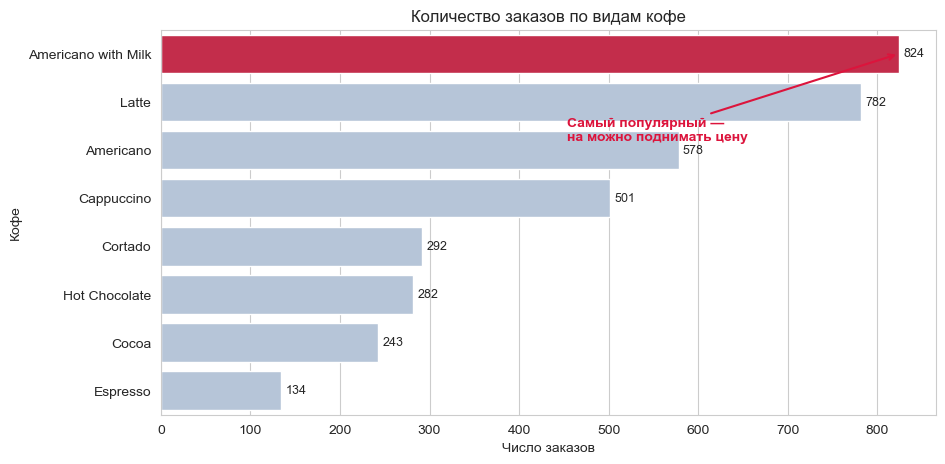

In [28]:
order = df['coffee_name'].value_counts()
plt.figure(figsize=(10, 5))
colors = ['crimson' if i == 0 else 'lightsteelblue' for i in range(len(order))]
sns.barplot(x=order.values, y=order.index, palette=colors)
plt.title('Количество заказов по видам кофе')
plt.xlabel('Число заказов'); plt.ylabel('Кофе')
for i, v in enumerate(order.values):
    plt.text(v + 5, i, str(v), va='center', fontsize=9)
plt.annotate('Самый популярный —\nна можно поднимать цену',
             xy=(order.values[0], 0), xytext=(order.values[0]*0.55, 1.8),
             arrowprops=dict(arrowstyle='->', color='crimson', lw=1.5),
             color='crimson', fontsize=10, fontweight='bold')
plt.show()

### Какой напиток приносит больше всего выручки?
Популярный по количеству ≠ самый прибыльный. Суммируем `money` по напиткам.

C:\Users\asus\AppData\Local\Temp\ipykernel_14368\907750648.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=revenue.values, y=revenue.index, palette=colors)


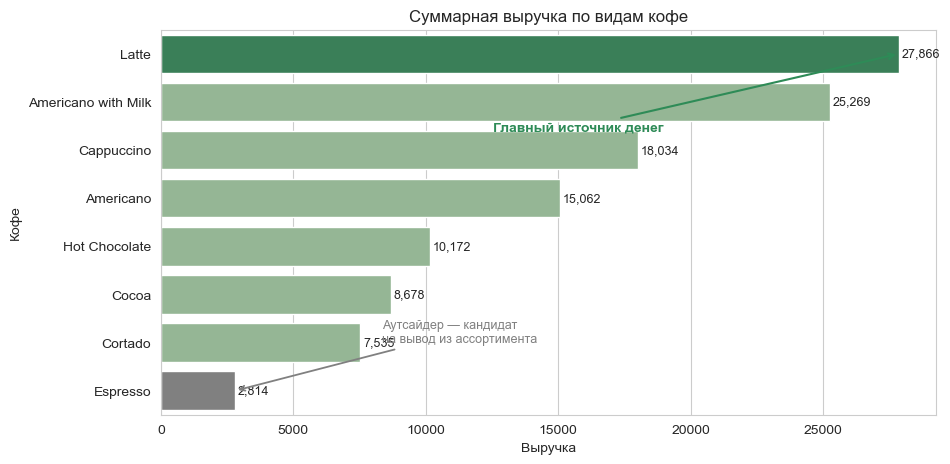

In [12]:
revenue = df.groupby('coffee_name')['money'].sum().sort_values(ascending=False)
plt.figure(figsize=(10, 5))
colors = ['seagreen' if i == 0 else ('grey' if i == len(revenue)-1 else 'darkseagreen')
          for i in range(len(revenue))]
sns.barplot(x=revenue.values, y=revenue.index, palette=colors)
plt.title('Суммарная выручка по видам кофе')
plt.xlabel('Выручка'); plt.ylabel('Кофе')
for i, v in enumerate(revenue.values):
    plt.text(v + 100, i, f'{v:,.0f}', va='center', fontsize=9)
plt.annotate('Главный источник денег',
             xy=(revenue.values[0], 0), xytext=(revenue.values[0]*0.45, 1.6),
             arrowprops=dict(arrowstyle='->', color='seagreen', lw=1.5),
             color='seagreen', fontsize=10, fontweight='bold')
plt.annotate('Аутсайдер — кандидат\nна вывод из ассортимента',
             xy=(revenue.values[-1], len(revenue)-1),
             xytext=(revenue.values[0]*0.3, len(revenue)-2),
             arrowprops=dict(arrowstyle='->', color='grey', lw=1.3),
             color='grey', fontsize=9)
plt.show()

###  Как распределены цены (чеки)?
Смотрим разброс суммы одного заказа.

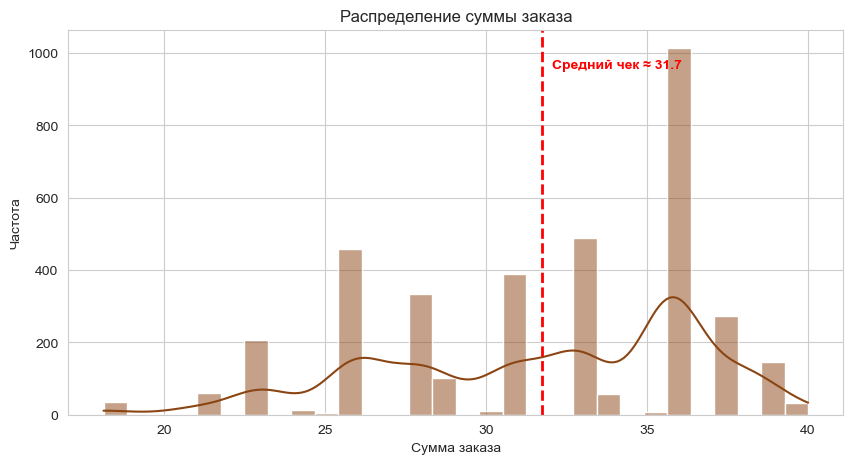

In [13]:
plt.figure(figsize=(10, 5))
sns.histplot(df['money'], bins=30, kde=True, color='saddlebrown')
mean_v = df['money'].mean()
plt.axvline(mean_v, color='red', ls='--', lw=2)
plt.text(mean_v + 0.3, plt.ylim()[1]*0.9, f'Средний чек ≈ {mean_v:.1f}',
         color='red', fontsize=10, fontweight='bold')
plt.title('Распределение суммы заказа')
plt.xlabel('Сумма заказа'); plt.ylabel('Частота')
plt.show()

###  Чем чаще платят — картой или наличными?
Сравниваем способы оплаты.

C:\Users\asus\AppData\Local\Temp\ipykernel_14368\3270831441.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='cash_type', palette='Set2')


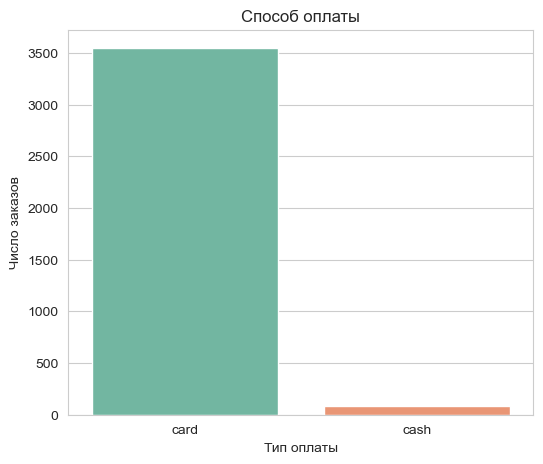

In [14]:
plt.figure(figsize=(6, 5))
sns.countplot(data=df, x='cash_type', palette='Set2')
plt.title('Способ оплаты')
plt.xlabel('Тип оплаты'); plt.ylabel('Число заказов')
plt.show()

###  В какие часы продаж больше всего?
Ищем пиковые часы спроса.

C:\Users\asus\AppData\Local\Temp\ipykernel_14368\92540406.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=hour_counts.index, y=hour_counts.values, palette=colors)


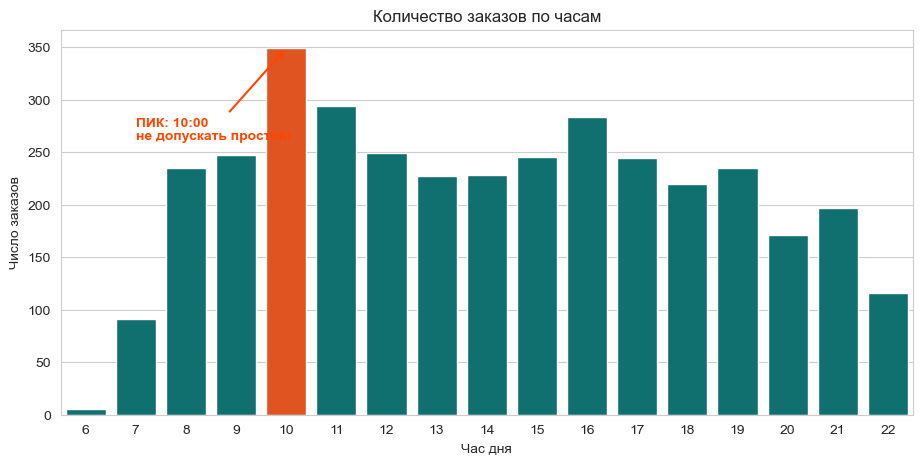

In [15]:
hour_counts = df['hour'].value_counts().sort_index()
peak_hour = hour_counts.idxmax()
plt.figure(figsize=(11, 5))
colors = ['orangered' if h == peak_hour else 'teal' for h in hour_counts.index]
sns.barplot(x=hour_counts.index, y=hour_counts.values, palette=colors)
plt.title('Количество заказов по часам')
plt.xlabel('Час дня'); plt.ylabel('Число заказов')
plt.annotate(f'ПИК: {peak_hour}:00\nне допускать простоя!',
             xy=(list(hour_counts.index).index(peak_hour), hour_counts.max()),
             xytext=(list(hour_counts.index).index(peak_hour)-3, hour_counts.max()*0.75),
             arrowprops=dict(arrowstyle='->', color='orangered', lw=1.5),
             color='orangered', fontsize=10, fontweight='bold')
plt.show()

###  Какой день недели самый загруженный?
Упорядочим дни от понедельника к воскресенью.

C:\Users\asus\AppData\Local\Temp\ipykernel_14368\826441818.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dow.index, y=dow.values, palette=colors)


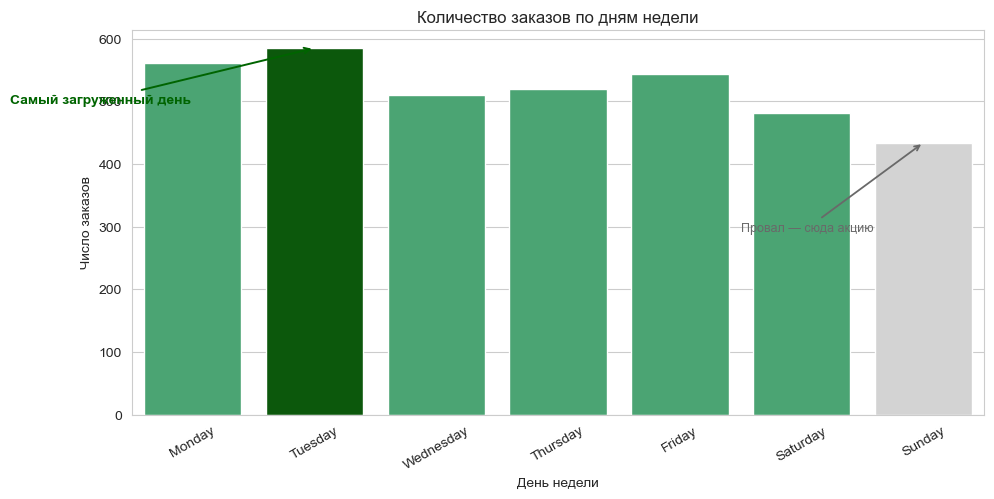

In [16]:
week_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow = df['day_of_week'].value_counts().reindex(week_order)
best, worst = dow.idxmax(), dow.idxmin()
plt.figure(figsize=(11, 5))
colors = ['darkgreen' if d == best else ('lightgrey' if d == worst else 'mediumseagreen')
          for d in week_order]
sns.barplot(x=dow.index, y=dow.values, palette=colors)
plt.title('Количество заказов по дням недели')
plt.xlabel('День недели'); plt.ylabel('Число заказов')
plt.xticks(rotation=30)
plt.annotate('Самый загруженный день',
             xy=(week_order.index(best), dow.max()),
             xytext=(week_order.index(best)-2.5, dow.max()*0.85),
             arrowprops=dict(arrowstyle='->', color='darkgreen', lw=1.4),
             color='darkgreen', fontsize=10, fontweight='bold')
plt.annotate('Провал — сюда акцию',
             xy=(week_order.index(worst), dow.min()),
             xytext=(week_order.index(worst)-1.5, dow.max()*0.5),
             arrowprops=dict(arrowstyle='->', color='dimgrey', lw=1.3),
             color='dimgrey', fontsize=9)
plt.show()

### Как менялись продажи по месяцам?
Смотрим динамику числа заказов во времени — есть ли рост или сезонность.

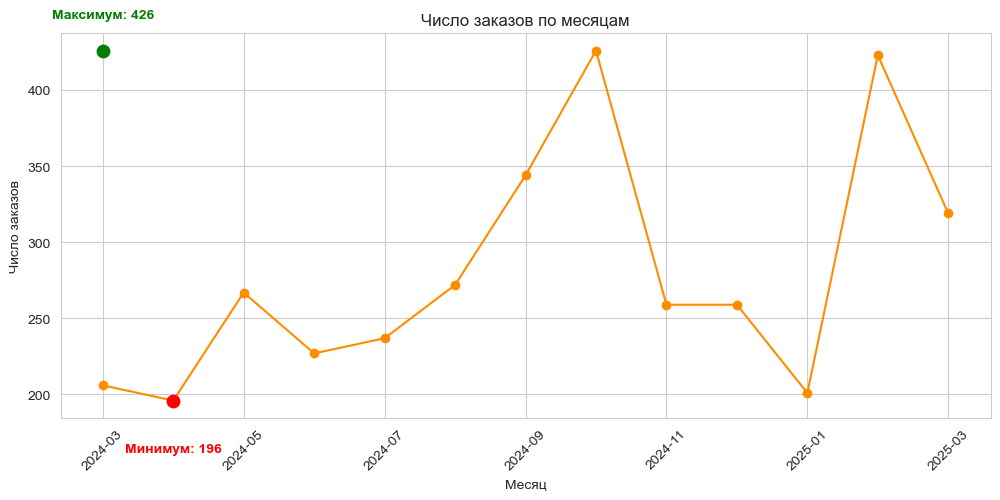

In [17]:
monthly = df.groupby('month').size()
plt.figure(figsize=(12, 5))
monthly.plot(marker='o', color='darkorange')
mx, mn = monthly.idxmax(), monthly.idxmin()
plt.scatter([mx],[monthly[mx]], color='green', zorder=5, s=80)
plt.scatter([mn],[monthly[mn]], color='red', zorder=5, s=80)
plt.annotate(f'Максимум: {monthly[mx]}',
             xy=(mx, monthly[mx]), xytext=(mx, monthly[mx]+monthly.max()*0.05),
             color='green', fontsize=10, fontweight='bold', ha='center')
plt.annotate(f'Минимум: {monthly[mn]}',
             xy=(mn, monthly[mn]), xytext=(mn, monthly[mn]-monthly.max()*0.08),
             color='red', fontsize=10, fontweight='bold', ha='center')
plt.title('Число заказов по месяцам')
plt.xlabel('Месяц'); plt.ylabel('Число заказов')
plt.xticks(rotation=45); plt.grid(True)
plt.show()

## как поднять выручку

Графики выше отвечали на вопрос «что происходит». Дальше — глазами владельца:
«где деньги и что с этим делать».

### В какие часы я зарабатываю больше всего?
Важно не число заказов, а **сумма выручки** — туда и направляем внимание (запас зёрен, молока, стаканов).

      orders   revenue
hour                  
6          5    149.40
7         91   2940.02
8        235   7017.88
9        247   7429.28
10       349  10994.52
11       294   8849.10
12       249   7668.62
13       227   7108.76
14       228   7265.80
15       245   7789.02
16       283   9221.60
17       244   7925.00
18       220   7235.60
19       235   7966.96
20       171   5656.92
21       197   6465.94
22       116   3747.16


C:\Users\asus\AppData\Local\Temp\ipykernel_14368\3170136865.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=by_hour.index, y=by_hour['revenue'], palette=colors)


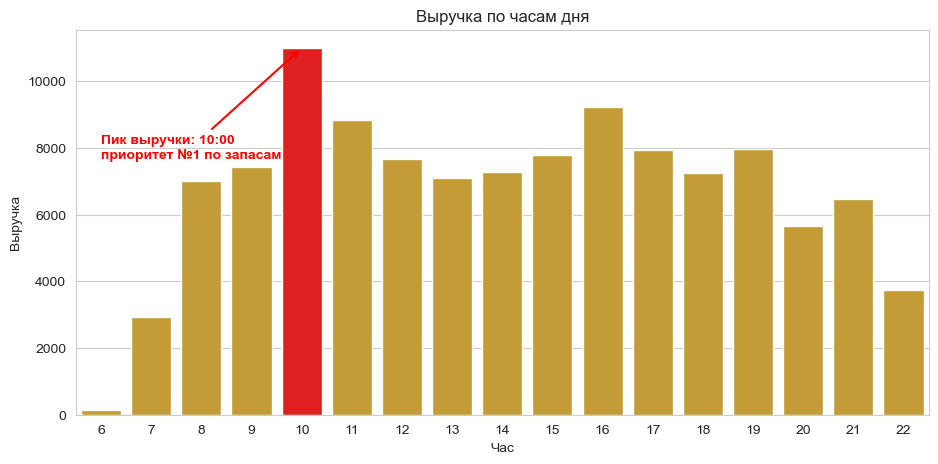


Пиковый по выручке час: 10:00 — здесь машина не должна простаивать.


In [19]:
# Выручка и число заказов по часам
by_hour = df.groupby('hour')['money'].agg(orders='count', revenue='sum')
print(by_hour)

peak = by_hour['revenue'].idxmax()
plt.figure(figsize=(11, 5))
colors = ['goldenrod' if h != peak else 'red' for h in by_hour.index]
sns.barplot(x=by_hour.index, y=by_hour['revenue'], palette=colors)
plt.title('Выручка по часам дня')
plt.xlabel('Час'); plt.ylabel('Выручка')
plt.annotate(f'Пик выручки: {peak}:00\nприоритет №1 по запасам',
             xy=(list(by_hour.index).index(peak), by_hour['revenue'].max()),
             xytext=(list(by_hour.index).index(peak)-4, by_hour['revenue'].max()*0.7),
             arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
             color='red', fontsize=10, fontweight='bold')
plt.show()
print(f'\nПиковый по выручке час: {peak}:00 — здесь машина не должна простаивать.')

###  Кто мои постоянники?
По анонимному `card` видно, кто возвращается. Постоянники — ядро выручки и кандидаты на программу лояльности.

Топ-10 постоянников:
                     visits    spent
card                                
ANON-0000-0000-0012     129  3785.92
ANON-0000-0000-0141     108  2749.78
ANON-0000-0000-1163      77  2278.22
ANON-0000-0000-0276      69  2119.54
ANON-0000-0000-0009      67  2343.98
ANON-0000-0000-0507      51  1797.30
ANON-0000-0000-0040      50  1519.48
ANON-0000-0000-0097      47  1477.86
ANON-0000-0000-1110      33   886.08
ANON-0000-0000-1170      32   850.32


C:\Users\asus\AppData\Local\Temp\ipykernel_14368\3558298807.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top10.values, y=top10.index, palette=colors)


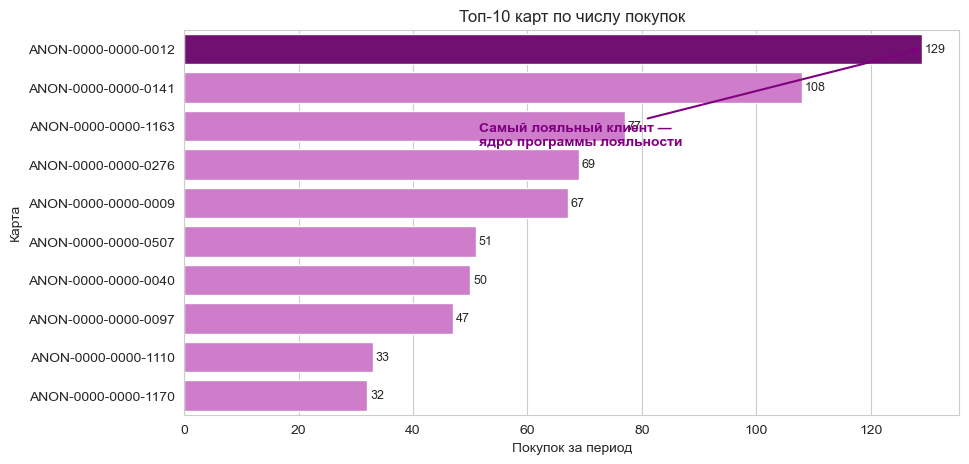

In [21]:
# Топ-10 карт по числу покупок и потраченной сумме
regulars = (df.dropna(subset=['card'])
              .groupby('card')['money']
              .agg(visits='count', spent='sum')
              .sort_values('visits', ascending=False))
print('Топ-10 постоянников:')
print(regulars.head(10))

top10 = regulars['visits'].head(10)
plt.figure(figsize=(10, 5))
colors = ['purple' if i == 0 else 'orchid' for i in range(10)]
sns.barplot(x=top10.values, y=top10.index, palette=colors)
plt.title('Топ-10 карт по числу покупок')
plt.xlabel('Покупок за период'); plt.ylabel('Карта')
for i, v in enumerate(top10.values):
    plt.text(v + 0.5, i, str(v), va='center', fontsize=9)
plt.annotate('Самый лояльный клиент —\nядро программы лояльности',
             xy=(top10.values[0], 0), xytext=(top10.values[0]*0.4, 2.5),
             arrowprops=dict(arrowstyle='->', color='purple', lw=1.5),
             color='purple', fontsize=10, fontweight='bold')
plt.show()

### Меняется ли средний чек по дням недели?
Где люди тратят охотнее — туда можно ставить акции на дорогие напитки.

C:\Users\asus\AppData\Local\Temp\ipykernel_14368\107758513.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_check.index, y=avg_check.values, palette='crest')


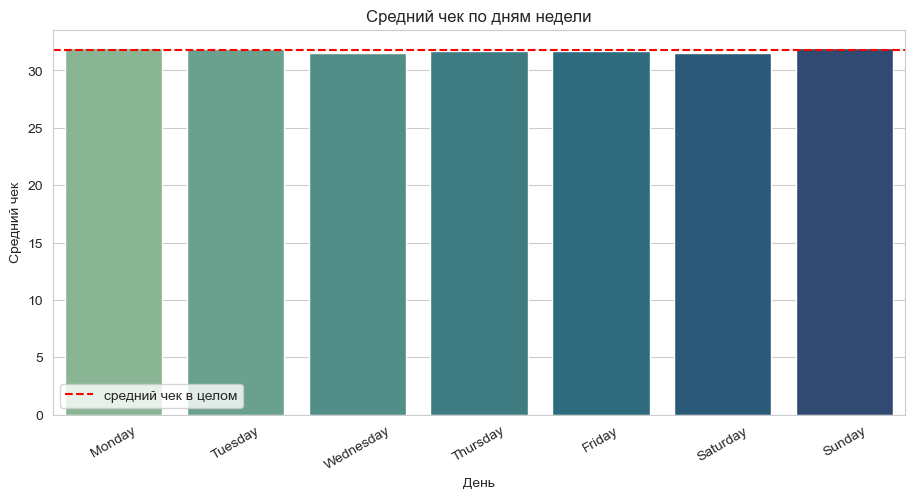

In [22]:
week_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
avg_check = df.groupby('day_of_week')['money'].mean().reindex(week_order)

plt.figure(figsize=(11, 5))
sns.barplot(x=avg_check.index, y=avg_check.values, palette='crest')
plt.axhline(df['money'].mean(), color='red', ls='--', label='средний чек в целом')
plt.title('Средний чек по дням недели')
plt.xlabel('День'); plt.ylabel('Средний чек')
plt.xticks(rotation=30); plt.legend()
plt.show()

###   Хит по количеству и хит по деньгам
Сводим в одну таблицу: что покупают часто и что реально приносит выручку. Это основа для решения о ценах.

In [23]:
summary = df.groupby('coffee_name')['money'].agg(
    orders='count', revenue='sum', avg_price='mean'
).sort_values('revenue', ascending=False)
summary['revenue_share'] = (summary['revenue'] / summary['revenue'].sum() * 100).round(1)
summary.round(2)

,orders,revenue,avg_price,revenue_share
coffee_name,,,,
Latte,782,27866.30,35.63,24.1
Americano with Milk,824,25269.12,30.67,21.9
Cappuccino,501,18034.14,36.00,15.6
Americano,578,15062.26,26.06,13.0
Hot Chocolate,282,10172.46,36.07,8.8
Cocoa,243,8678.16,35.71,7.5
Cortado,292,7534.86,25.80,6.5
Espresso,134,2814.28,21.00,2.4


## 🧾 Выводы для владельца

1. **Не допускать простоя в пиковые по выручке часы** — там зарабатывается основная сумма.
2. **Поднять цену на самый популярный напиток на 1–2 ед.** — спрос на кофе неэластичный, прибыль вырастет почти без потери заказов.
3. **Запустить акцию в «мёртвые» часы** (скидка) — заполняем пустое время, себестоимость низкая.
4. **Программа лояльности по картам** — ядро постоянников даёт заметную долю выручки, их выгодно удерживать («6-й кофе бесплатно»).
5. **Убрать/не пополнять аутсайдеров** из таблицы — они занимают бункер и не приносят денег.

Итог: рост выручки **без новых вложений** — только за счёт работы с уже имеющимися данными.

## Что покупают постоянные клиенты?

Постоянник — карта с 2+ покупками. Узнаем их любимые напитки и сравним
с разовыми клиентами: совпадают ли вкусы и на чём держится «ядро» выручки.

In [24]:
# Делим клиентов на постоянных и разовых по числу покупок карты
card_visits = df.dropna(subset=['card']).groupby('card')['money'].count()
regular_cards = card_visits[card_visits >= 2].index   # 2+ покупок

df_card = df.dropna(subset=['card']).copy()
df_card['segment'] = df_card['card'].isin(regular_cards).map(
    {True: 'Постоянные', False: 'Разовые'})

print(df_card['segment'].value_counts())

segment
Постоянные    2776
Разовые        771
Name: count, dtype: int64


### Любимые напитки постоянных клиентов
Топ заказов внутри сегмента постоянников.

C:\Users\asus\AppData\Local\Temp\ipykernel_14368\2278423163.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=regular_fav.values, y=regular_fav.index, palette='flare')


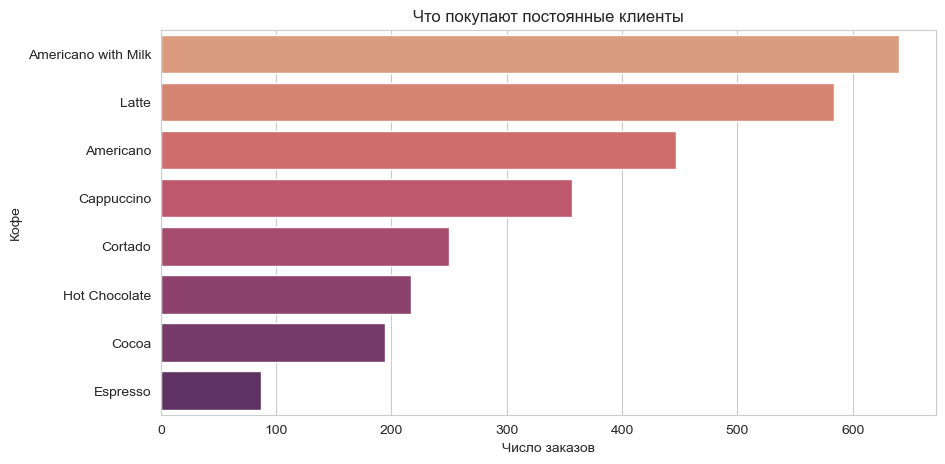

Любимый напиток постоянников: Americano with Milk


In [25]:
regular_fav = (df_card[df_card['segment'] == 'Постоянные']['coffee_name']
               .value_counts())

plt.figure(figsize=(10, 5))
sns.barplot(x=regular_fav.values, y=regular_fav.index, palette='flare')
plt.title('Что покупают постоянные клиенты')
plt.xlabel('Число заказов'); plt.ylabel('Кофе')
plt.show()

print('Любимый напиток постоянников:', regular_fav.idxmax())

### Постоянные против разовых: различаются ли вкусы?
Доля каждого напитка внутри сегмента (в %), чтобы сравнивать честно при разном размере групп.

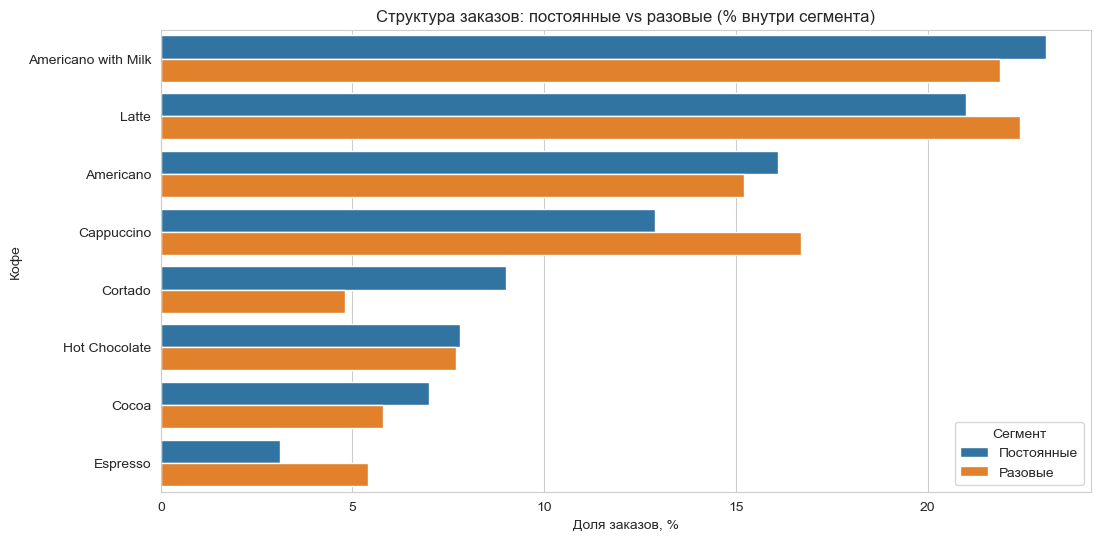

In [26]:
# Доля напитка внутри каждого сегмента
mix = (df_card.groupby('segment')['coffee_name']
       .value_counts(normalize=True)
       .mul(100).round(1)
       .rename('share').reset_index())

plt.figure(figsize=(12, 6))
sns.barplot(data=mix, y='coffee_name', x='share', hue='segment')
plt.title('Структура заказов: постоянные vs разовые (% внутри сегмента)')
plt.xlabel('Доля заказов, %'); plt.ylabel('Кофе')
plt.legend(title='Сегмент')
plt.show()

### Вклад напитков в выручку от постоянников
Что именно приносит деньги в «ядре» клиентов.

C:\Users\asus\AppData\Local\Temp\ipykernel_14368\1605371161.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=reg_revenue.values, y=reg_revenue.index, palette='magma')


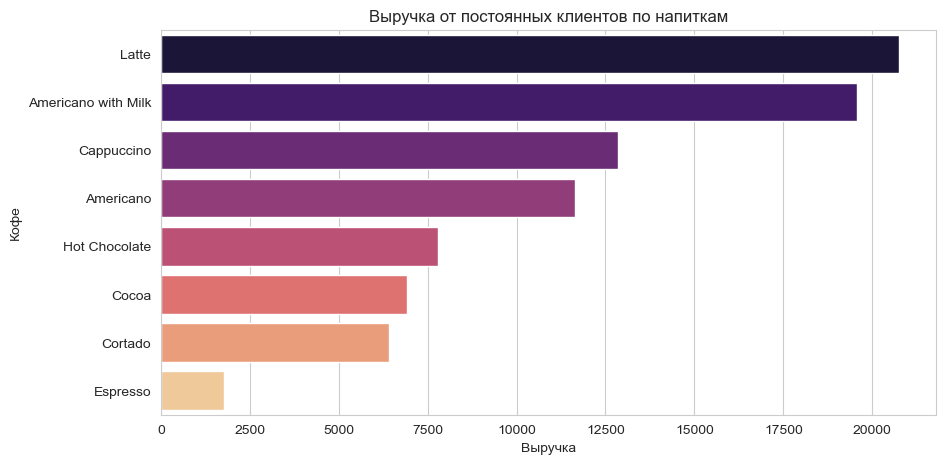

In [27]:
reg_revenue = (df_card[df_card['segment'] == 'Постоянные']
               .groupby('coffee_name')['money'].sum()
               .sort_values(ascending=False))

plt.figure(figsize=(10, 5))
sns.barplot(x=reg_revenue.values, y=reg_revenue.index, palette='magma')
plt.title('Выручка от постоянных клиентов по напиткам')
plt.xlabel('Выручка'); plt.ylabel('Кофе')
plt.show()

# 📌 Итоговый Summary

**Данные:** ~3636 продаж кофемашины за год (март 2024 — март 2025), средний чек ≈ 31.7, 8 видов напитков.

### Ключевые находки
- **Хит по количеству ≠ хит по деньгам.** Самый частый напиток — Americano with Milk, но основную выручку формируют более дорогие позиции.
- **Есть чёткие пиковые часы** — там делается основная выручка, простой в пик = прямая потеря.
- **Бизнес держится на постоянниках.** Небольшая доля карт даёт заметную часть выручки (есть карта со 129 покупками за год).
- **Вкусы постоянных и разовых клиентов** позволяют понять, вокруг какого напитка строить лояльность.

### Рекомендации владельцу (без вложений)
1. **Поднять цену на самый популярный напиток на 1–2 ед.** — спрос неэластичный, прибыль растёт почти без потери заказов.
2. **Не допускать простоя в пиковые по выручке часы**, а в «мёртвые» часы запускать скидку.
3. **Программа лояльности по картам** («6-й кофе бесплатно») — удержание постоянников дешевле привлечения новых.
4. **Чистить ассортимент** — не пополнять напитки-аутсайдеры.

### Самая ценная информация в данных
`card` (ID клиента) — единственное, что связывает покупки в одного человека во времени и позволяет считать retention, LTV и частоту. Данные о **клиенте** ценнее данных о **товаре**.

> **Вывод:** рост выручки достижим за счёт трёх рычагов — продавать *дороже* (цена хита), *чаще* (работа с часами) и *удерживать* (лояльность) — используя только уже имеющиеся данные.